In [1]:
import os
import time
import torch
import random
import numpy as np
import csv
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from thop import profile

from mobileslidenet import MobileSlideNet


# =========================
# Dataset
# =========================
class CleanImageFolder(ImageFolder):
    def find_classes(self, directory):
        classes = []
        for d in os.listdir(directory):
            full = os.path.join(directory, d)
            if os.path.isdir(full) and not d.startswith("."):
                classes.append(d)
        classes.sort()
        class_to_idx = {cls: i for i, cls in enumerate(classes)}
        return classes, class_to_idx


# =========================
# data path
# =========================
data_root = "./datasets"
train_dir = os.path.join(data_root, "train")
val_dir   = os.path.join(data_root, "val")
test_dir  = os.path.join(data_root, "test")


# =========================
# config
# =========================
img_size = 224
num_classes = 3
batch_size = 64
num_epochs = 100
ablation_stage = 5
lr = 0.01
temperature = 4.0
alpha = 0.5
beta = 0.1
num_workers = 10


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =========================
# seed
# =========================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


# =========================
# transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


# =========================
# dataset
# =========================
train_ds = CleanImageFolder(train_dir, transform=train_transform)
val_ds   = CleanImageFolder(val_dir, transform=val_transform)
test_ds  = CleanImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=8)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=8)
test_loader = DataLoader(
    test_ds, batch_size=batch_size,
    shuffle=False, num_workers=num_workers, pin_memory=True
)


# =========================
#  model
# =========================
student_model = MobileSlideNet(num_classes=num_classes).to(device)


# =========================
# loss
# =========================
ce_loss_fn = nn.CrossEntropyLoss()


Using device: cuda


In [2]:
# =========================
# Hardware Info
# =========================
print("\n========== System Info ==========")

# CPU
import platform
print("CPU:", platform.processor())
print("Architecture:", platform.machine())
print("System:", platform.system(), platform.release())

# RAM
try:
    import psutil
    mem = psutil.virtual_memory()
    print(f"RAM: {mem.total / 1024**3:.2f} GB")
except:
    print("RAM: psutil not installed")

# GPU
if torch.cuda.is_available():
    print("\n========== GPU Info ==========")
    print("GPU Count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"\nGPU {i}:")
        print("Name:", torch.cuda.get_device_name(i))
        print("Capability:", torch.cuda.get_device_capability(i))
        print("Total Memory (GB):",
              round(torch.cuda.get_device_properties(i).total_memory / 1024**3, 2))
        print("CUDA Version:", torch.version.cuda)
else:
    print("\nNo CUDA GPU detected")

print("================================\n")


========== System Info ==========
CPU: x86_64
Architecture: x86_64
System: Linux 5.15.0-105-generic
RAM: 54.91 GB

========== GPU Info ==========
GPU Count: 1

GPU 0:
Name: NVIDIA GeForce RTX 4090
Capability: (8, 9)
Total Memory (GB): 23.54
CUDA Version: 12.1



In [3]:
student_model.eval()
dummy_input = torch.randn(1, 3, img_size, img_size).to(device)
student_model(dummy_input)
flops, params = profile(student_model, inputs=(dummy_input,))
model_size_bytes = sum(p.numel() * p.element_size() for p in student_model.parameters())
model_size_mb = model_size_bytes / (1024*1024)
total_layers = len(list(student_model.modules()))
params_m = params / 1e6  
flops_g = flops / 1e9  
flops_m = flops / 1e6  
flops_k = flops / 1e3  
print(f"\nStudent Model Summary:")
print(f"\nmodel summary: {total_layers} layers, "
      f"{params_m:.2f}M parameters, {params_m:.2f}M gradients, "
      f"{flops_g:.2f} GFLOPs, {flops_m:.1f} MFLOPs, {flops_k:.1f} KFLOPs, "
      f"{model_size_mb:.2f} MB model size")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv1d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.

Student Model Summary:

model summary: 168 layers, 0.15M parameters, 0.15M gradients, 0.09 GFLOPs, 90.6 MFLOPs, 90610.2 KFLOPs, 0.58 MB model size


In [4]:
def kd_loss(a, b, T=4.0):
    return F.kl_div(
        F.log_softmax(a / T, dim=1),
        F.softmax(b / T, dim=1),
        reduction="batchmean"
    ) * (T * T)


def train_one_epoch(model, loader, optimizer, device,
                    temperature=4.0, alpha=0.5):

    model.train()

    ce = nn.CrossEntropyLoss(label_smoothing=0.1)

    total_ce = 0
    total_logits = 0
    total_feat = 0
    correct = 0
    total = 0

    for x, y in loader:

        x, y = x.to(device), y.to(device)

        logits, feats, final_logits, final_feat = model(x)

        # =========================
        # CE loss
        # =========================
        ce_loss = ce(final_logits, y)

        logits_loss = 0.0
        feat_loss = 0.0

        # =========================
        # GSD loss
        # =========================
        for i in range(min(len(logits), ablation_stage)):

            # feature distillation
            feat_loss += F.mse_loss(
                feats[i],
                final_feat.detach()
            )

            # logits distillation
            logits_loss += kd_loss(
                logits[i],
                final_logits.detach(),
                temperature
            )

        loss = ce_loss + logits_loss + alpha * feat_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # =========================
        # stats
        # =========================
        total_ce += ce_loss.item()
        total_logits += logits_loss.item()
        total_feat += feat_loss.item()

        correct += (final_logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return (
        total_ce / len(loader),
        total_logits / len(loader),
        total_feat / len(loader),
        correct / total
    )

# =========================
# eval
# =========================
@torch.no_grad()
def evaluate(model, loader, device):

    model.eval()

    ce_loss_fn = nn.CrossEntropyLoss()

    total_ce = 0
    total_logits = 0
    total_feat = 0
    correct = 0
    total = 0

    for x, y in tqdm(loader, desc="Eval"):

        x, y = x.to(device), y.to(device)

        _, _, final_logits, _ = model(x)

        ce_loss = ce_loss_fn(final_logits, y)

        total_ce += ce_loss.item()
        total_logits += 0.0
        total_feat += 0.0

        correct += (final_logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return (
        total_ce / len(loader),
        total_logits,
        total_feat,
        correct / total
    )

import time
import platform

print("\n========== Device Info ==========")
print("Device:", device)

print("CPU:", platform.processor())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)


# =========================
# optimizer & scheduler
# =========================
optimizer = torch.optim.SGD(
    student_model.parameters(),
    lr=lr,
    momentum=0.9,
    weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)


# =========================
# FLOPs
# =========================
student_model.eval()
dummy = torch.randn(1, 3, img_size, img_size).to(device)
_ = student_model(dummy)

flops, params = profile(student_model, inputs=(dummy,))
print(f"Params: {params/1e6:.2f}M | FLOPs: {flops/1e9:.2f}G")


# =========================
# save
# =========================
os.makedirs('./Result/5/Train_csv', exist_ok=True)
os.makedirs('./Result/5/model_save', exist_ok=True)

csv_file = './Result/5/Train_csv/basel.csv'
best_model_path = './Result/5/model_save/best.pth'
last_model_path = './Result/5/model_save/last.pth'


# =========================
# resume
# =========================
resume_mode = "last"
start_epoch = 1
best_val_acc = 0.0

if resume_mode == "last" and os.path.exists(last_model_path):
    checkpoint = torch.load(last_model_path, map_location=device)
    student_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint.get('best_val_acc', 0.0)

    print(f"resume from epoch {start_epoch}")


# =========================
# CSV
# =========================
if not os.path.exists(csv_file):
    with open(csv_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'epoch',
            'train_CE',
            'train_L_logits',
            'train_L_feat',
            'train_acc',
            'val_CE',
            'val_L_logits',
            'val_L_feat',
            'val_acc'
])

total_start_time = time.time()

# =========================
# train loop
# =========================
for epoch in range(start_epoch, num_epochs + 1):

    torch.cuda.synchronize() if torch.cuda.is_available() else None
    t0 = time.time()

    train_ce, train_logits, train_feat, train_acc = train_one_epoch(
        student_model, train_loader, optimizer, device
    )

    val_ce, val_logits, val_feat, val_acc = evaluate(
        student_model, val_loader, device
    )

    scheduler.step()

    print(f"[Epoch {epoch}] "
          f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    # =========================
    # save last
    # =========================
    torch.save({
        'epoch': epoch,
        'model_state_dict': student_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_acc': best_val_acc
    }, last_model_path)

    # =========================
    # save best
    # =========================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': student_model.state_dict(),
            'best_val_acc': best_val_acc
        }, best_model_path)

    # =========================
    # CSV log
    # =========================
    with open(csv_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch,
            train_ce,
            train_logits,
            train_feat,
            train_acc,
            val_ce,
    val_logits,
    val_feat,
    val_acc
])

    print("time:", time.time() - t0)
    epoch_time = time.time() - t0

    if torch.cuda.is_available():
        print(f"GPU Memory Allocated: {torch.cuda.memory_allocated()/1024**3:.3f} GB")
        print(f"GPU Memory Reserved: {torch.cuda.memory_reserved()/1024**3:.3f} GB")

    print(f"Epoch Time: {epoch_time:.2f} sec")

total_end_time = time.time()
total_time = total_end_time - total_start_time

print("\n========== Training Summary ==========")
print(f"Total Training Time: {total_time/3600:.2f} hours")
print(f"Total Training Time: {total_time/60:.2f} minutes")
print(f"Total Training Time: {total_time:.2f} seconds")

if torch.cuda.is_available():
    print(f"Final GPU Memory Allocated: {torch.cuda.memory_allocated()/1024**3:.3f} GB")
    print(f"Final GPU Memory Reserved: {torch.cuda.memory_reserved()/1024**3:.3f} GB")


========== Device Info ==========
Device: cuda
CPU: x86_64
GPU Name: NVIDIA GeForce RTX 4090
CUDA Version: 12.1
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv1d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
Params: 0.15M | FLOPs: 0.09G
resume from epoch 101

========== Training Summary ==========
Total Training Time: 0.00 hours
Total Training Time: 0.00 minutes
Total Training Time: 0.00 seconds
Final GPU Memory Allocated: 0.036 GB
Final GPU Memory Reserved: 0.168 GB


In [5]:
import os
import time
import torch
import numpy as np
from tqdm import tqdm


student_model.eval()

preds_all = []
labels_all = []
logits_all = []

total_infer_time = 0.0
total_images = 0
latency_list = []


# =========================
# Warm-up
# =========================
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)

        # ⭐ FIX 1
        _, _, _, _ = student_model(imgs)

        if device.type == "cuda":
            torch.cuda.synchronize()
        break


# =========================
# Test loop
# =========================
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Test"):

        imgs = imgs.to(device)
        labels = labels.to(device)

        if device.type == "cuda":
            torch.cuda.synchronize()
        start_time = time.perf_counter()

        # ⭐ FIX 1
        logits_list, feats_list, outputs, final_feat = student_model(imgs)

        if device.type == "cuda":
            torch.cuda.synchronize()
        end_time = time.perf_counter()

        batch_time = end_time - start_time
        batch_size = imgs.size(0)

        total_infer_time += batch_time
        total_images += batch_size

        per_image_latency = batch_time / batch_size
        latency_list.extend([per_image_latency] * batch_size)

        # ⭐ FIX 2
        preds = outputs.argmax(dim=1)

        preds_all.extend(preds.cpu().tolist())
        labels_all.extend(labels.cpu().tolist())

        # ⭐ FIX 3
        logits_all.append(outputs.cpu())


# =========================
# Stack outputs
# =========================
y_true = torch.tensor(labels_all)
y_pred = torch.tensor(preds_all)
logits_all = torch.cat(logits_all, dim=0)

total = y_true.numel()


# =========================
# Top-1 / Top-5 Accuracy
# =========================
num_classes = logits_all.size(1)
max_k = min(5, num_classes)

_, topk_preds = logits_all.topk(max_k, dim=1, largest=True, sorted=True)
y_true_expand = y_true.view(-1, 1).expand_as(topk_preds)

topk_correct = (topk_preds == y_true_expand)

top1_acc = topk_correct[:, :1].any(dim=1).float().mean().item() * 100
top5_acc = topk_correct.any(dim=1).float().mean().item() * 100


# =========================
# Accuracy / Error Rate
# =========================
correct = (y_true == y_pred).sum().item()
test_acc = correct / total
test_error = 1.0 - test_acc


# =========================
# Precision
# =========================
num_classes = len(test_ds.classes)
conf_mat = torch.zeros(num_classes, num_classes, dtype=torch.int64)

for t, p in zip(y_true, y_pred):
    conf_mat[t, p] += 1

precision_per_class = []
for c in range(num_classes):
    tp = conf_mat[c, c]
    fp = conf_mat[:, c].sum() - tp
    if tp + fp == 0:
        precision_per_class.append(0.0)
    else:
        precision_per_class.append((tp / (tp + fp)).item())

test_precision = sum(precision_per_class) / num_classes


# =========================
# FPS / Latency
# =========================
fps = total_images / total_infer_time

latency_np = np.array(latency_list) * 1000
avg_latency = latency_np.mean()
max_latency = latency_np.max()
p95_latency = np.percentile(latency_np, 95)


# =========================
# Print
# =========================
print("\n========== Test Results ==========")
print(f"Test samples             : {total}")
print(f"Top-1 Accuracy (%)       : {top1_acc:.2f}")
print(f"Accuracy                 : {test_acc:.4f}")
print(f"Error Rate               : {test_error:.4f}")
print(f"Precision (macro)        : {test_precision:.4f}")
print("----------------------------------")
print(f"FPS                      : {fps:.2f}")
print(f"Avg Latency (ms)         : {avg_latency:.2f}")
print(f"P95 Latency (ms)        : {p95_latency:.2f}")
print("==================================\n")

# =========================
# Save
# =========================
save_dir = "./Result/5"
os.makedirs(save_dir, exist_ok=True)

out_pred_file = os.path.join(save_dir, "test_preds.txt")

with open(out_pred_file, "w") as f:
    for p, t in zip(preds_all, labels_all):
        f.write(f"{p}\t{t}\n")

print(f"Predictions saved to {out_pred_file}")

Test: 100%|██████████| 14/14 [00:01<00:00, 13.31it/s]


========== Test Results ==========
Test samples             : 855
Top-1 Accuracy (%)       : 99.77
Accuracy                 : 0.9977
Error Rate               : 0.0023
Precision (macro)        : 0.9984
----------------------------------
FPS                      : 6652.82
Avg Latency (ms)         : 0.15
P95 Latency (ms)        : 0.27

Predictions saved to ./Result/5/test_preds.txt


In [6]:
from sklearn.metrics import accuracy_score
# 获取类别到ID的映射字典
id2name = {idx: cls for cls, idx in train_ds.class_to_idx.items()}

student_model.eval()

y_true_list, y_pred_probs_list = [], []

# =================== 收集预测 ===================
with torch.no_grad():
    for imgs, labels in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        # ⭐ FIX（关键）
        _, _, outputs, _ = student_model(imgs)

        probs = torch.softmax(outputs, dim=1)

        y_pred_probs_list.append(probs.cpu())
        y_true_list.append(labels.cpu())


y_pred_probs = torch.cat(y_pred_probs_list, dim=0)
y_true = torch.cat(y_true_list, dim=0)


# =================== 预测类别 ===================
y_pred = torch.argmax(y_pred_probs, dim=1)


# =================== 平均置信度 ===================
confidence_scores = torch.max(y_pred_probs, dim=1).values
avg_confidence_per_class = []

print("\n===== 平均置信度 =====")
for cls in range(num_classes):
    idxs = (y_true == cls)
    if idxs.sum() > 0:
        avg_conf = confidence_scores[idxs].mean().item()
    else:
        avg_conf = 0.0

    avg_confidence_per_class.append(avg_conf)
    print(f"Class {id2name.get(cls, str(cls))}: {avg_conf:.4f}")


# =================== 每类指标 ===================
tp, fp, fn = [], [], []

for cls in range(num_classes):
    tp_cls = ((y_pred == cls) & (y_true == cls)).sum().item()
    fp_cls = ((y_pred == cls) & (y_true != cls)).sum().item()
    fn_cls = ((y_pred != cls) & (y_true == cls)).sum().item()

    tp.append(tp_cls)
    fp.append(fp_cls)
    fn.append(fn_cls)

precision_per_class = [
    tp[i] / (tp[i] + fp[i]) if (tp[i] + fp[i]) > 0 else 0.0
    for i in range(num_classes)
]

recall_per_class = [
    tp[i] / (tp[i] + fn[i]) if (tp[i] + fn[i]) > 0 else 0.0
    for i in range(num_classes)
]

f1_per_class = [
    2 * p * r / (p + r) if (p + r) > 0 else 0.0
    for p, r in zip(precision_per_class, recall_per_class)
]


print("\n===== 每类指标 =====")
for cls in range(num_classes):
    print(
        f"Class {id2name.get(cls, str(cls))}: "
        f"Precision={precision_per_class[cls]:.4f}, "
        f"Recall={recall_per_class[cls]:.4f}, "
        f"F1={f1_per_class[cls]:.4f}"
    )


accuracy = accuracy_score(
    y_true.numpy(),
    y_pred.numpy()
)

macro_precision = np.mean(precision_per_class)
macro_recall = np.mean(recall_per_class)
macro_f1 = np.mean(f1_per_class)


print("\n===== Overall Performance =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")


===== 平均置信度 =====
Class Debris-flow: 0.9172
Class Landslide: 0.9317
Class Normal: 0.9282

===== 每类指标 =====
Class Debris-flow: Precision=1.0000, Recall=0.9545, F1=0.9767
Class Landslide: Precision=0.9977, Recall=0.9977, F1=0.9977
Class Normal: Precision=0.9975, Recall=1.0000, F1=0.9988

===== Overall Performance =====
Accuracy: 0.9977
Macro Precision: 0.9984
Macro Recall: 0.9841
Macro F1-score: 0.9911


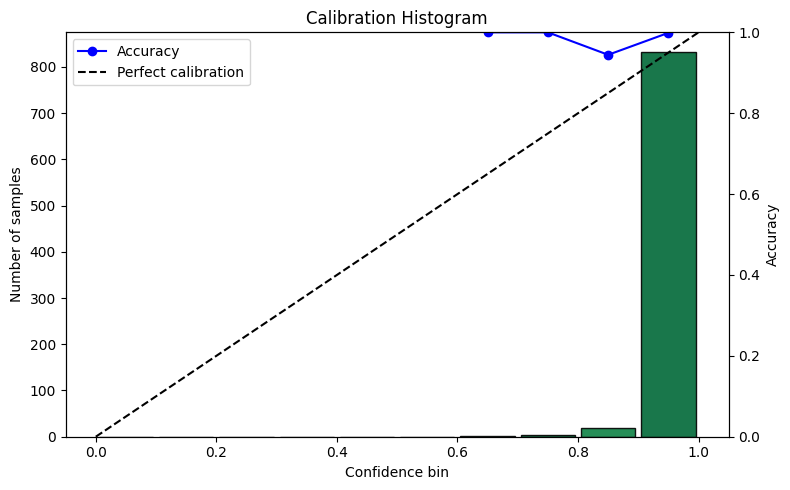

[OK] Saved to: ./Result/5/Calibration/calibration_hist.png


In [7]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

confidence_scores_list = []
y_true_list = []
y_pred_list = []

student_model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits, feats, final_logits, final_feat = student_model(imgs)

        probs = torch.softmax(final_logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        y_true_list.append(labels.cpu())
        y_pred_list.append(preds.cpu())

        confidence_scores_list.extend(
            torch.max(probs, dim=1).values.cpu().tolist()
        )

y_true = torch.cat(y_true_list, dim=0).numpy()
y_pred = torch.cat(y_pred_list, dim=0).numpy()
conf = np.array(confidence_scores_list)

bins = np.linspace(0.0, 1.0, 11)
bin_idx = np.digitize(conf, bins) - 1

bin_acc = []
bin_conf = []
bin_counts = []

for b in range(10):
    idxs = np.where(bin_idx == b)[0]

    if len(idxs) == 0:
        bin_acc.append(np.nan)
        bin_conf.append((bins[b] + bins[b + 1]) / 2)
        bin_counts.append(0)
        continue

    bin_counts.append(len(idxs))
    bin_conf.append(conf[idxs].mean())
    bin_acc.append((y_pred[idxs] == y_true[idxs]).mean())

bin_positions = (bins[:-1] + bins[1:]) / 2

save_dir = "./Result/5/Calibration"
os.makedirs(save_dir, exist_ok=True)

fig_path = os.path.join(save_dir, "calibration_hist.png")

# ===============================
# 绘图
# ===============================
plt.figure(figsize=(8, 5))

# 柱状图（样本数）
cmap = plt.get_cmap("RdYlGn")
colors = [
    cmap(a) if not np.isnan(a) else (0.9, 0.9, 0.9, 1.0)
    for a in bin_acc
]

plt.bar(bin_positions, bin_counts, width=0.09,
        color=colors, edgecolor="k", alpha=0.9)

plt.xlabel("Confidence bin")
plt.ylabel("Number of samples")
plt.title("Calibration Histogram")

# ===============================
# 可靠性曲线（右轴）
# ===============================
ax2 = plt.twinx()

ax2.plot(bin_positions, bin_acc,
         marker="o", color="blue", label="Accuracy")

ax2.plot([0, 1], [0, 1],
         "k--", label="Perfect calibration")

ax2.set_ylim(0, 1)
ax2.set_ylabel("Accuracy")

ax2.legend(loc="upper left")

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"[OK] Saved to: {fig_path}")

Test: 100%|██████████| 14/14 [00:00<00:00, 14.20it/s]


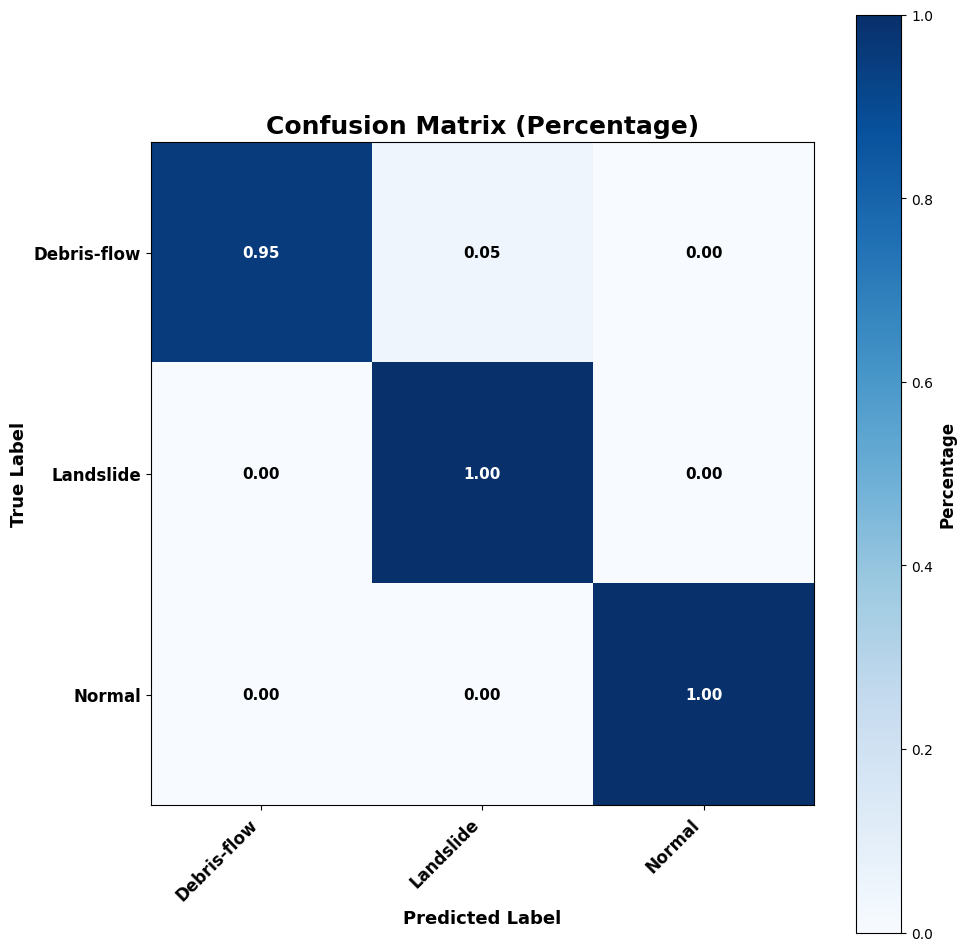

[OK] saved to: ./Result/5/confusion_matrix/confusion_matrix.tif


In [8]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# ===============================
# class names
# ===============================
class_names = train_ds.classes
num_classes = len(class_names)

# ===============================
# containers
# ===============================
y_true_list = []
y_pred_list = []

student_model.eval()

# ===============================
# inference
# ===============================
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Test"):

        imgs = imgs.to(device)
        labels = labels.to(device)

      
        logits, feats, final_logits, final_feat = student_model(imgs)

        preds = torch.argmax(final_logits, dim=1)

        y_true_list.append(labels.cpu())
        y_pred_list.append(preds.cpu())

# ===============================
# concat
# ===============================
y_true_np = torch.cat(y_true_list).numpy()
y_pred_np = torch.cat(y_pred_list).numpy()

# ===============================
# confusion matrix
# ===============================
conf_matrix = confusion_matrix(
    y_true_np,
    y_pred_np,
    labels=list(range(num_classes))
)

conf_matrix_percentage = conf_matrix.astype('float') / (
    conf_matrix.sum(axis=1, keepdims=True) + 1e-8
)

# ===============================
# save path
# ===============================
save_fig_dir = "./Result/5/confusion_matrix"
os.makedirs(save_fig_dir, exist_ok=True)

fig_path = os.path.join(save_fig_dir, "confusion_matrix.tif")

# ===============================
# plot
# ===============================
plt.figure(figsize=(10, 10))
im = plt.imshow(conf_matrix_percentage, cmap="Blues")

plt.title("Confusion Matrix (Percentage)", fontsize=18, weight="bold")

cbar = plt.colorbar(im)
cbar.set_label("Percentage", fontsize=12, weight="bold")

ticks = np.arange(num_classes)
plt.xticks(ticks, class_names, rotation=45, ha="right", fontsize=12, weight="bold")
plt.yticks(ticks, class_names, fontsize=12, weight="bold")

plt.xlabel("Predicted Label", fontsize=13, weight="bold")
plt.ylabel("True Label", fontsize=13, weight="bold")

# ===============================
# annotate
# ===============================
for i in range(num_classes):
    for j in range(num_classes):
        val = conf_matrix_percentage[i, j]
        plt.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            weight="bold",
            color="white" if val > 0.5 else "black"
        )

plt.tight_layout()

# ===============================
# save
# ===============================
plt.savefig(fig_path, dpi=300, format="tif", bbox_inches="tight")
plt.show()

print(f"[OK] saved to: {fig_path}")

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os  
import pandas as pd  


support_rates = np.diag(conf_matrix_percentage)
unsupport_rates = 1 - support_rates
class_idx = np.arange(len(support_rates))


save_csv_dir = './Result/5/support_unsupport'  
os.makedirs(save_csv_dir, exist_ok=True)   
csv_name = 'support_unsupport_rates.csv'
csv_path = os.path.join(save_csv_dir, csv_name)

df = pd.DataFrame({'Class': class_names,
                   'SupportRate': support_rates,
                   'UnsupportRate': unsupport_rates})
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'Support & Unsupport rates saved to {csv_path}')

Support & Unsupport rates saved to ./Result/5/support_unsupport/support_unsupport_rates.csv


In [10]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# =========================
# model eval mode
# =========================
student_model.eval()

y_score_list = []
y_true_list = []

# =========================
# inference
# =========================
with torch.no_grad():
    for imgs, labels in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        _, _, final_logits, _ = student_model(imgs)

        # =========================
        # softmax → probability of class 1
        # =========================
        probs = torch.softmax(final_logits, dim=1)

        # 取正类概率（class 1）
        pos_probs = probs[:, 1]

        y_score_list.append(pos_probs.cpu())
        y_true_list.append(labels.cpu())

# =========================
# concat
# =========================
y_score = torch.cat(y_score_list, dim=0).numpy()
y_true = torch.cat(y_true_list, dim=0).numpy()

# =========================
# ROC curve
# =========================
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# =========================
# save path
# =========================
save_dir = "./Result/5/ROC_AUC"
os.makedirs(save_dir, exist_ok=True)

fig_path = os.path.join(save_dir, "ROC_AUC_binary.tif")

# =========================
# plot
# =========================
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"ROC curve (AUC = {roc_auc:.4f})"
)

# diagonal line
plt.plot([0, 1], [0, 1], "k--", lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend(loc="lower right")

plt.grid(False)
plt.tight_layout()

# =========================
# save
# =========================
plt.savefig(fig_path, dpi=300, format="tif")
plt.show()

print(f"[OK] ROC saved to: {fig_path}")
print(f"AUC = {roc_auc:.4f}")

ValueError: multiclass format is not supported

In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# ===============================
# model eval
# ===============================
student_model.eval()

y_score_list = []
y_true_list = []

with torch.no_grad():
    for imgs, labels in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        _, _, final_logits, _ = student_model(imgs)

        probs = torch.softmax(final_logits, dim=1)

        y_score_list.append(probs.cpu())
        y_true_list.append(labels.cpu())

# ===============================
# concat
# ===============================
y_score = torch.cat(y_score_list, dim=0).numpy()
y_true = torch.cat(y_true_list, dim=0).numpy()

# ===============================
# safety check
# ===============================
n_classes = y_score.shape[1]

# ===============================
# binarize
# ===============================
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

# ===============================
# PR + AP
# ===============================
precision = {}
recall = {}
average_precision = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    average_precision[i] = average_precision_score(
        y_true_bin[:, i],
        y_score[:, i]
    )

# ===============================
# mAP
# ===============================
mAP = np.mean(list(average_precision.values()))

# ===============================
# plot
# ===============================
save_dir = "./Result/5/mAP"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(
        recall[i],
        precision[i],
        label=f"Class {i} (AP={average_precision[i]:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (mAP={mAP:.4f})")
plt.legend()
plt.grid(False)
plt.tight_layout()

fig_path = os.path.join(save_dir, "PR_curve.tif")
plt.savefig(fig_path, dpi=300, format="tif")
plt.show()

print(f"[OK] PR saved: {fig_path}")
print(f"mAP = {mAP:.4f}")

Feature shape: (13281, 128)


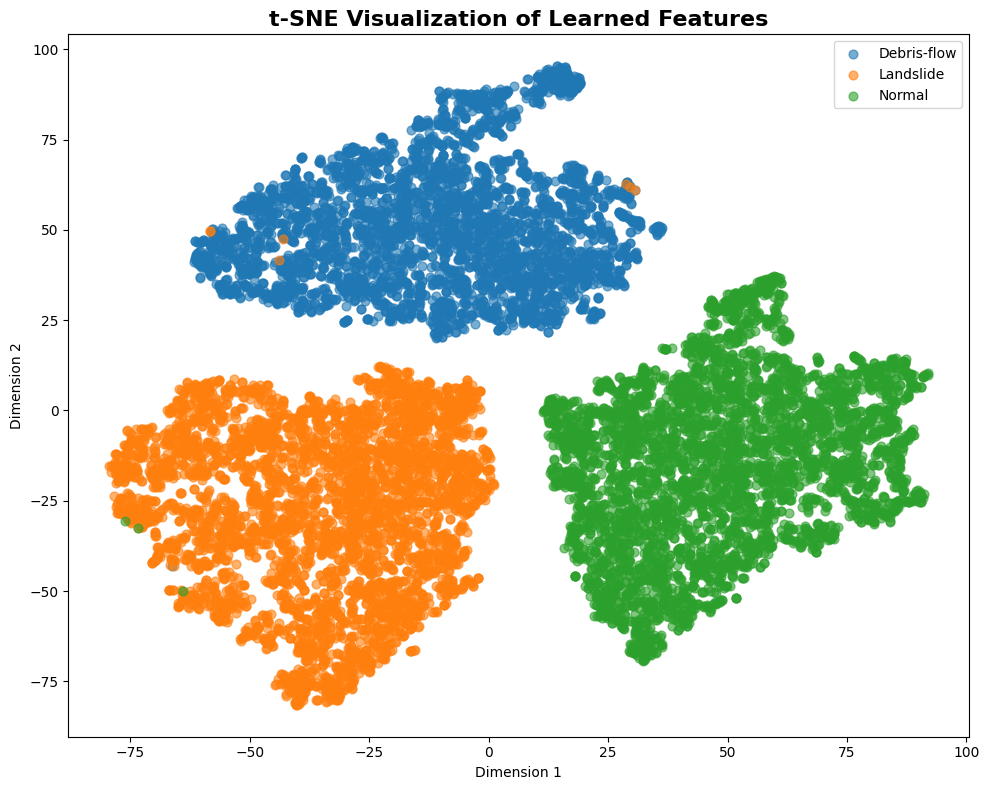

[OK] saved to: ./Result/5/TSNE/tsne_features.tif


In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


student_model.eval()

all_feats_list = []
all_labels_list = []

# ===============================
# 提取 feature
# ===============================
with torch.no_grad():
    for split, loader in {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }.items():

        for imgs, labels in loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            
            logits, feats, final_logits, final_feat = student_model(imgs)

            # use feature
            feat = final_feat.cpu()

            all_feats_list.append(feat)
            all_labels_list.append(labels.cpu())

# ===============================
# concat
# ===============================
all_feats = torch.cat(all_feats_list, dim=0).numpy()
all_labels = torch.cat(all_labels_list, dim=0).numpy()

print("Feature shape:", all_feats.shape)

# ===============================
# t-SNE
# ===============================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

feats_2d = tsne.fit_transform(all_feats)

# ===============================
# plot
# ===============================
plt.figure(figsize=(10, 8))

for cls in np.unique(all_labels):
    idx = (all_labels == cls)

    plt.scatter(
        feats_2d[idx, 0],
        feats_2d[idx, 1],
        label=id2name[cls],
        alpha=0.6,
        s=40
    )

plt.title("t-SNE Visualization of Learned Features", fontsize=16, fontweight="bold")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend()
plt.grid(False)

# ===============================
# save
# ===============================
save_dir = "./Result/5/TSNE"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "tsne_features.tif")

plt.tight_layout()
plt.savefig(save_path, dpi=300, format="tif")
plt.show()

print(f"[OK] saved to: {save_path}")

In [12]:
import os
import cv2
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.nn as nn
from PIL import Image
import numpy as np


class_mapping = {'Debris-flow': 0, 'Landslide': 1, 'Normal': 2}

class_names = list(class_mapping.keys())
num_classes = len(class_names)


test_root = r"./datasets/test"
model_path = r"./Result/5/model_save/best.pth"
save_root = "./Result/5/GM"
os.makedirs(save_root, exist_ok=True)

# ===============================
# device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# transform
# ===============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ===============================
# model
# ===============================
student_model = MobileSlideNet(num_classes=num_classes).to(device)

checkpoint = torch.load(model_path, map_location=device)
student_model.load_state_dict(checkpoint["model_state_dict"], strict=False)

student_model.eval()
print("Model loaded")

def find_last_conv2d(model):
    for m in reversed(list(model.modules())):
        if isinstance(m, nn.Conv2d):
            return m
    raise ValueError("No Conv2d found")

target_layer = find_last_conv2d(student_model)

# ===============================
# hooks
# ===============================
feature_maps = None
gradients = None

def forward_hook(module, inp, out):
    global feature_maps
    feature_maps = out.detach()

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0].detach()

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# ===============================
# GradCAM
# ===============================
print("Running GradCAM...")

for cls in os.listdir(test_root):

    cls_path = os.path.join(test_root, cls)
    if not os.path.isdir(cls_path):
        continue

    save_dir = os.path.join(save_root, cls)
    os.makedirs(save_dir, exist_ok=True)

    for img_name in os.listdir(cls_path):

        img_path = os.path.join(cls_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)

        input_tensor = transform(img_pil).unsqueeze(0).to(device)

        # =========================
        # forward
        # =========================
        logits, feats, final_logits, final_feat = student_model(input_tensor)

        
        pred_class = final_logits.argmax(dim=1)

        score = final_logits[0, pred_class]

        student_model.zero_grad()
        score.backward()

        # hook
        if feature_maps is None or gradients is None:
            continue

        # =========================
        # CAM
        # =========================
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * feature_maps).sum(dim=1).squeeze()

        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-7)

        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

        save_path = os.path.join(save_dir, img_name)
        cv2.imwrite(save_path, overlay)

print("GradCAM Finished")

Model loaded
Running GradCAM...
GradCAM Finished
